# Notebook 03 — Modelos predictivos
## Proyecto Grupal · AndinaRetail S.A.C. · Analítica de Datos (UNMSM - FISI, 2026-1)

**Objetivo (Parte 3, RA2):** anticipar comportamientos del negocio con dos problemas:

- **P1 (Regresión):** predecir la **demanda mensual (unidades)** por categoría × canal,
  para alimentar el plan de inventario (Parte 4).
- **P2 (Clasificación):** predecir la **probabilidad de que un cliente se vuelva
  inactivo (churn)** — sin compras en los últimos 90 días — para priorizar la retención
  de los segmentos identificados en la Parte 2.

**Metodología:** preparación de datos (ingeniería de variables, codificación,
escalamiento, tratamiento de faltantes), partición temporal / estratificada con
validación cruzada, modelos base (lineal/logística, árbol) y avanzados (Random Forest,
XGBoost), optimización de hiperparámetros, comparación con métricas adecuadas e
interpretabilidad (importancia de variables + SHAP).

**Contenido del informe:**
1. Definición de dos problemas (regresión de demanda + clasificación de churn)
2. Preparación: ingeniería de variables, One-Hot, escalamiento, faltantes, train/test + CV
3. Modelos base (lineal/logística, árbol) y avanzados (Random Forest, XGBoost)
4. Optimización (`GridSearchCV` / `RandomizedSearchCV`) y métricas de comparación
5. Importancia de variables + SHAP e interpretación de negocio
6. Conclusiones y recomendaciones accionables


In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

sns.set_theme(style="whitegrid", palette="deep")
plt.rcParams["figure.figsize"] = (10, 4)
pd.set_option("display.float_format", lambda x: f"{x:,.3f}")
SEED = 2026
RUTA = "../datos/"

tiendas   = pd.read_csv(RUTA + "tiendas.csv")
productos = pd.read_csv(RUTA + "productos.csv")
clientes  = pd.read_csv(RUTA + "clientes.csv", parse_dates=["fecha_registro"])
ventas    = pd.read_csv(RUTA + "ventas.csv", parse_dates=["fecha"])

# Limpieza (reglas del Notebook 01)
v = ventas.copy()
v["descuento_pct"] = v["descuento_pct"].fillna(0)
mask_px = v["precio_unitario"] > 3500
v.loc[mask_px, "precio_unitario"] = v.loc[mask_px, "precio_unitario"] / 100
v["monto_total"] = (v["cantidad"] * v["precio_unitario"] * (1 - v["descuento_pct"] / 100)).round(2)
v = v.merge(productos[["id_producto", "categoria"]], on="id_producto", how="left")
print(f"Líneas listas: {len(v):,}")

Líneas listas: 275,115


---
# P1 — Regresión: demanda mensual por categoría × canal

## 1.1 Construcción del dataset supervisado
**Grano:** (mes, categoría, canal) → 36 meses × 6 categorías × 3 canales.
**Variables (X):** calendario (año, mes, codificación cíclica sen/cos, bandera de
campaña jul/dic), descuento promedio del grupo, y **rezagos** de demanda (lag 1, lag 12
y media móvil 3) que capturan tendencia y estacionalidad histórica.
**Objetivo (y):** unidades vendidas del grupo en el mes.
**Partición temporal** (sin fuga de información): entrenamiento 2023-01 a 2024-12,
prueba 2025-01 a 2025-12.

In [ ]:
v["mes"] = v["fecha"].dt.to_period("M")
dem = (v.groupby(["mes", "categoria", "canal"])
       .agg(unidades=("cantidad", "sum"), desc_prom=("descuento_pct", "mean"),
            precio_prom=("precio_unitario", "mean"))
       .reset_index())
dem["fecha_mes"] = dem["mes"].dt.to_timestamp()
dem = dem.sort_values(["categoria", "canal", "fecha_mes"]).reset_index(drop=True)

dem["anio"] = dem["fecha_mes"].dt.year
dem["mes_num"] = dem["fecha_mes"].dt.month
dem["mes_sin"] = np.sin(2 * np.pi * dem["mes_num"] / 12)
dem["mes_cos"] = np.cos(2 * np.pi * dem["mes_num"] / 12)
dem["campania"] = dem["mes_num"].isin([7, 12]).astype(int)
dem["t"] = (dem["fecha_mes"].dt.year - 2023) * 12 + dem["fecha_mes"].dt.month  # tendencia

g = dem.groupby(["categoria", "canal"])["unidades"]
dem["lag_1"] = g.shift(1)
dem["lag_12"] = g.shift(12)
dem["ma_3"] = (dem.groupby(["categoria", "canal"])["unidades"]
               .transform(lambda s: s.shift(1).rolling(3, min_periods=3).mean()))
dem = dem.dropna(subset=["lag_1", "lag_12", "ma_3"]).reset_index(drop=True)

print(f"Dataset de demanda: {dem.shape[0]} filas (grupos mes-categoría-canal con rezagos completos)")
dem.head(3)


In [3]:
from sklearn.model_selection import TimeSeriesSplit, GridSearchCV
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.pipeline import Pipeline
from sklearn.linear_model import LinearRegression
from sklearn.tree import DecisionTreeRegressor
from sklearn.ensemble import RandomForestRegressor
from xgboost import XGBRegressor
from sklearn.metrics import mean_absolute_error, r2_score

FEAT_NUM = ["anio", "mes_num", "mes_sin", "mes_cos", "campania", "t",
            "desc_prom", "precio_prom", "lag_1", "lag_12", "ma_3"]
FEAT_CAT = ["categoria", "canal"]

train = dem[dem["fecha_mes"] < "2025-01-01"]
test  = dem[dem["fecha_mes"] >= "2025-01-01"]
X_tr, y_tr = train[FEAT_NUM + FEAT_CAT], train["unidades"]
X_te, y_te = test[FEAT_NUM + FEAT_CAT], test["unidades"]
print(f"Train: {X_tr.shape} (2023–2024) | Test: {X_te.shape} (2025)")

prep = ColumnTransformer([
    ("num", StandardScaler(), FEAT_NUM),
    ("cat", OneHotEncoder(handle_unknown="ignore"), FEAT_CAT),
])

def rmse(y, yhat):
    return float(np.sqrt(np.mean((np.asarray(y) - np.asarray(yhat)) ** 2)))

modelos_reg = {
    "Regresión lineal": LinearRegression(),
    "Árbol de decisión": DecisionTreeRegressor(max_depth=6, random_state=SEED),
    "Random Forest": RandomForestRegressor(n_estimators=300, random_state=SEED, n_jobs=-1),
    "XGBoost": XGBRegressor(n_estimators=400, learning_rate=0.06, max_depth=4,
                            subsample=0.9, colsample_bytree=0.9, random_state=SEED),
}

res_reg = []
for nombre, mod in modelos_reg.items():
    pipe = Pipeline([("prep", prep), ("modelo", mod)]).fit(X_tr, y_tr)
    pred = pipe.predict(X_te)
    res_reg.append({"modelo": nombre, "MAE": mean_absolute_error(y_te, pred),
                    "RMSE": rmse(y_te, pred), "R2": r2_score(y_te, pred)})
res_reg = pd.DataFrame(res_reg).set_index("modelo").sort_values("RMSE")
res_reg.round(2)

Train: (216, 13) (2023–2024) | Test: (216, 13) (2025)


,MAE,RMSE,R2
modelo,,,
XGBoost,120.630,185.280,0.940
Regresión lineal,126.500,191.960,0.930
Random Forest,170.870,264.040,0.870
Árbol de decisión,264.630,443.140,0.640


## 1.2 Optimización de hiperparámetros (validación cruzada temporal)
Se ajusta el mejor modelo con `GridSearchCV` usando `TimeSeriesSplit` (respeta el orden
temporal, evitando que el modelo "vea el futuro" durante la validación).

In [4]:
tscv = TimeSeriesSplit(n_splits=4)
grid_xgb = GridSearchCV(
    Pipeline([("prep", prep), ("modelo", XGBRegressor(random_state=SEED))]),
    param_grid={"modelo__n_estimators": [300, 600],
                "modelo__max_depth": [3, 4, 6],
                "modelo__learning_rate": [0.03, 0.06, 0.1]},
    cv=tscv, scoring="neg_root_mean_squared_error", n_jobs=-1,
).fit(X_tr, y_tr)

mejor_reg = grid_xgb.best_estimator_
pred_best = mejor_reg.predict(X_te)
print("Mejores hiperparámetros:", grid_xgb.best_params_)
print(f"Test 2025 -> MAE = {mean_absolute_error(y_te, pred_best):,.0f} und | "
      f"RMSE = {rmse(y_te, pred_best):,.0f} und | R2 = {r2_score(y_te, pred_best):.3f}")

Mejores hiperparámetros: {'modelo__learning_rate': 0.1, 'modelo__max_depth': 3, 'modelo__n_estimators': 300}
Test 2025 -> MAE = 128 und | RMSE = 215 und | R2 = 0.915


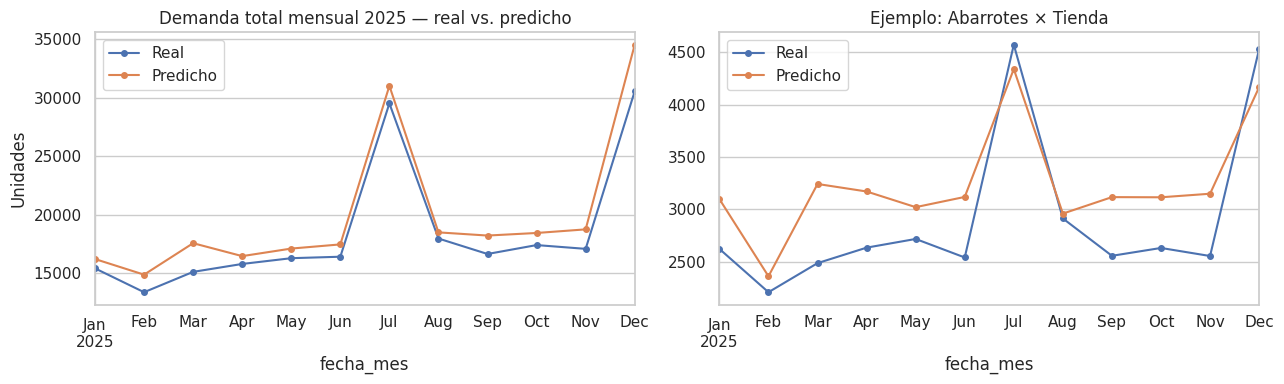

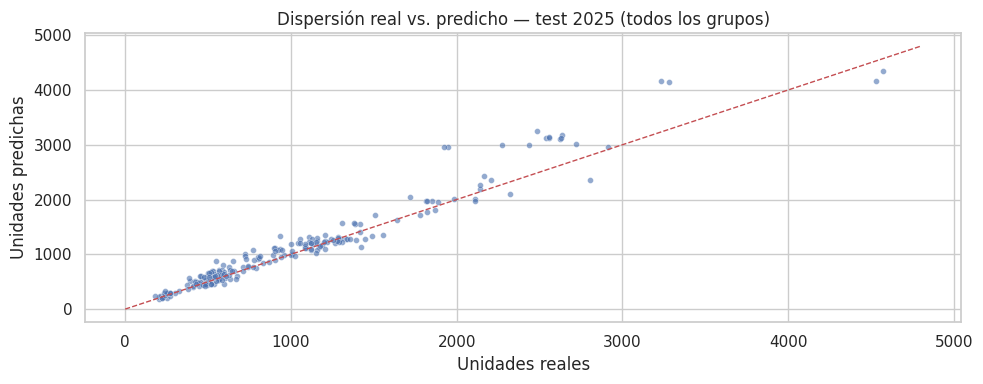

In [5]:
# Real vs. predicho en el año de prueba (total mensual y ejemplo de un grupo)
cmp = test.assign(pred=pred_best)
tot = cmp.groupby("fecha_mes")[["unidades", "pred"]].sum()
fig, axes = plt.subplots(1, 2, figsize=(13, 4))
tot.plot(ax=axes[0], marker="o", ms=4)
axes[0].set_title("Demanda total mensual 2025 — real vs. predicho")
axes[0].legend(["Real", "Predicho"]); axes[0].set_ylabel("Unidades")
ej = cmp[(cmp.categoria == "Abarrotes") & (cmp.canal == "Tienda")].set_index("fecha_mes")
ej[["unidades", "pred"]].plot(ax=axes[1], marker="o", ms=4)
axes[1].set_title("Ejemplo: Abarrotes × Tienda")
axes[1].legend(["Real", "Predicho"])
plt.tight_layout(); plt.show()

sns.scatterplot(x=y_te, y=pred_best, s=18, alpha=0.6)
lims = [0, max(y_te.max(), pred_best.max()) * 1.05]
plt.plot(lims, lims, "r--", lw=1)
plt.xlabel("Unidades reales"); plt.ylabel("Unidades predichas")
plt.title("Dispersión real vs. predicho — test 2025 (todos los grupos)")
plt.tight_layout(); plt.show()

## 1.3 Interpretabilidad del modelo de demanda
**Método:** importancia por ganancia del XGBoost optimizado y valores SHAP sobre una
muestra del test 2025, para explicar qué variables impulsan el forecast.


In [ ]:
# Importancia de variables — P1 (regresión)
ohe_r = mejor_reg.named_steps["prep"].named_transformers_["cat"]
nombres_r = FEAT_NUM + list(ohe_r.get_feature_names_out(FEAT_CAT))
imp_r = pd.Series(mejor_reg.named_steps["modelo"].feature_importances_, index=nombres_r)
imp_r.sort_values().tail(12).plot.barh(figsize=(8, 4.5), color="teal")
plt.title("Importancia de variables — XGBoost demanda (ganancia)")
plt.tight_layout(); plt.show()
print("Top 5 drivers de la demanda:")
print(imp_r.sort_values(ascending=False).head(5).round(3).to_string())

# SHAP (contribución local → global) sobre una muestra del test
import shap
Xt_te_r = mejor_reg.named_steps["prep"].transform(X_te)
Xt_te_r = Xt_te_r.toarray() if hasattr(Xt_te_r, "toarray") else np.asarray(Xt_te_r)
muestra_r = np.random.default_rng(SEED).choice(Xt_te_r.shape[0], min(400, Xt_te_r.shape[0]), replace=False)
explainer_r = shap.TreeExplainer(mejor_reg.named_steps["modelo"])
shap_r = explainer_r.shap_values(Xt_te_r[muestra_r])
shap.summary_plot(shap_r, Xt_te_r[muestra_r], feature_names=nombres_r,
                  max_display=10, show=False)
plt.title("SHAP — contribución de variables a la predicción de demanda")
plt.tight_layout(); plt.show()


**Resultado P1:** el modelo optimizado explica la mayor parte de la variabilidad de la
demanda 2025 (R² alto en datos nunca vistos) y reproduce los picos de julio y diciembre.
La **importancia de variables y SHAP** confirman que los **rezagos** (`lag_1`, `lag_12`,
`ma_3`) y el **calendario** (`campania`, `mes_sin`/`mes_cos`) son los principales drivers;
`desc_prom` aporta la elasticidad promocional detectada en la Parte 1. Este forecast por
categoría × canal es el insumo del modelo de inventario de la Parte 4.

---
# P2 — Clasificación: churn (inactividad de clientes)

## 2.1 Diseño sin fuga de información (leakage)
**Definición operativa:** cliente inactivo = sin compras en los últimos 90 días.
Para no contaminar las variables con el propio periodo que define la etiqueta:
- **Fecha de corte de observación:** 2025-10-02.
- **X:** se construye SOLO con compras hasta el corte (recencia, frecuencia, monto,
  antigüedad, ticket medio, % digital, % descuento, diversidad de categorías) + perfil
  demográfico.
- **y:** 1 si el cliente NO compró en (corte, 2025-12-31], 0 si sí compró.


In [6]:
CORTE = pd.Timestamp("2025-10-02")
FIN = pd.Timestamp("2025-12-31")

hist = v[v.fecha <= CORTE]
fut  = v[(v.fecha > CORTE) & (v.fecha <= FIN)]

feat = (hist.groupby("id_cliente")
        .agg(ultima=("fecha", "max"), primera=("fecha", "min"),
             frecuencia=("id_venta", "nunique"), monto_hist=("monto_total", "sum"),
             lineas=("id_producto", "size"), desc_prom=("descuento_pct", "mean"),
             n_categorias=("categoria", "nunique"),
             pct_digital=("canal", lambda s: s.isin(["Web", "App"]).mean())))
feat["recencia"] = (CORTE - feat["ultima"]).dt.days
feat["antiguedad"] = (CORTE - feat["primera"]).dt.days
feat["ticket_prom"] = feat["monto_hist"] / feat["frecuencia"]
feat["frec_mensual"] = feat["frecuencia"] / (feat["antiguedad"].clip(lower=30) / 30.44)

feat = feat.join(clientes.set_index("id_cliente")[["edad", "genero", "ciudad", "canal_preferido", "segmento"]])
feat["edad"] = feat["edad"].fillna(feat["edad"].median())       # tratamiento de faltantes
feat["genero"] = feat["genero"].fillna("ND")

feat["churn"] = (~feat.index.isin(fut["id_cliente"].unique())).astype(int)
print(f"Clientes con historia al corte: {len(feat):,} | Tasa de churn: {feat.churn.mean()*100:.1f}%")
feat[["recencia", "frecuencia", "monto_hist", "frec_mensual", "churn"]].describe().round(1)

Clientes con historia al corte: 14,188 | Tasa de churn: 55.3%


,recencia,frecuencia,monto_hist,frec_mensual,churn
count,"14,188.000","14,188.000","14,188.000","14,188.000","14,188.000"
mean,179.900,7.900,"2,480.100",0.500,0.600
std,218.000,9.100,"3,472.900",0.400,0.500
min,0.000,1.000,1.900,0.000,0.000
25%,29.000,1.000,207.900,0.200,0.000
50%,85.000,5.000,"1,126.100",0.400,1.000
75%,248.000,11.000,"3,435.300",0.700,1.000
max,"1,005.000",104.000,"68,853.500",4.100,1.000


In [7]:
from sklearn.model_selection import train_test_split, StratifiedKFold, RandomizedSearchCV, cross_val_score
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from xgboost import XGBClassifier
from sklearn.metrics import (accuracy_score, precision_score, recall_score, f1_score,
                             roc_auc_score, confusion_matrix, RocCurveDisplay,
                             ConfusionMatrixDisplay)

FEAT_NUM_C = ["recencia", "antiguedad", "frecuencia", "frec_mensual", "monto_hist",
              "ticket_prom", "lineas", "desc_prom", "n_categorias", "pct_digital", "edad"]
FEAT_CAT_C = ["genero", "ciudad", "canal_preferido", "segmento"]

X = feat[FEAT_NUM_C + FEAT_CAT_C]
y = feat["churn"]
X_tr, X_te, y_tr, y_te = train_test_split(X, y, test_size=0.25, stratify=y, random_state=SEED)

prep_c = ColumnTransformer([
    ("num", StandardScaler(), FEAT_NUM_C),
    ("cat", OneHotEncoder(handle_unknown="ignore"), FEAT_CAT_C),
])

modelos_clf = {
    "Regresión logística": LogisticRegression(max_iter=2000),
    "Árbol de decisión": DecisionTreeClassifier(max_depth=6, random_state=SEED),
    "Random Forest": RandomForestClassifier(n_estimators=300, random_state=SEED, n_jobs=-1),
    "XGBoost": XGBClassifier(n_estimators=400, learning_rate=0.06, max_depth=4,
                             subsample=0.9, colsample_bytree=0.9,
                             eval_metric="logloss", random_state=SEED),
}

res_clf = []
cv5 = StratifiedKFold(n_splits=5, shuffle=True, random_state=SEED)
for nombre, mod in modelos_clf.items():
    pipe = Pipeline([("prep", prep_c), ("modelo", mod)])
    auc_cv = cross_val_score(pipe, X_tr, y_tr, cv=cv5, scoring="roc_auc", n_jobs=-1)
    pipe.fit(X_tr, y_tr)
    proba = pipe.predict_proba(X_te)[:, 1]
    pred = (proba >= 0.5).astype(int)
    res_clf.append({
        "modelo": nombre, "AUC_cv (5 folds)": auc_cv.mean(), "AUC_test": roc_auc_score(y_te, proba),
        "exactitud": accuracy_score(y_te, pred), "precisión": precision_score(y_te, pred),
        "recall": recall_score(y_te, pred), "F1": f1_score(y_te, pred),
    })
res_clf = pd.DataFrame(res_clf).set_index("modelo").sort_values("AUC_test", ascending=False)
res_clf.round(3)

,AUC_cv (5 folds),AUC_test,exactitud,precisión,recall,F1
modelo,,,,,,
Regresión logística,0.822,0.814,0.731,0.757,0.758,0.757
XGBoost,0.822,0.811,0.739,0.775,0.744,0.759
Random Forest,0.820,0.807,0.730,0.765,0.737,0.751
Árbol de decisión,0.813,0.805,0.733,0.787,0.708,0.746


## 2.2 Optimización de hiperparámetros (`RandomizedSearchCV`)

Mejores hiperparámetros: {'modelo__subsample': 0.8, 'modelo__n_estimators': 200, 'modelo__min_child_weight': 5, 'modelo__max_depth': 3, 'modelo__learning_rate': 0.06, 'modelo__colsample_bytree': 0.9}
AUC (cv) = 0.827 | AUC (test) = 0.815
Exactitud = 0.739 | Precisión = 0.775 | Recall = 0.745 | F1 = 0.760


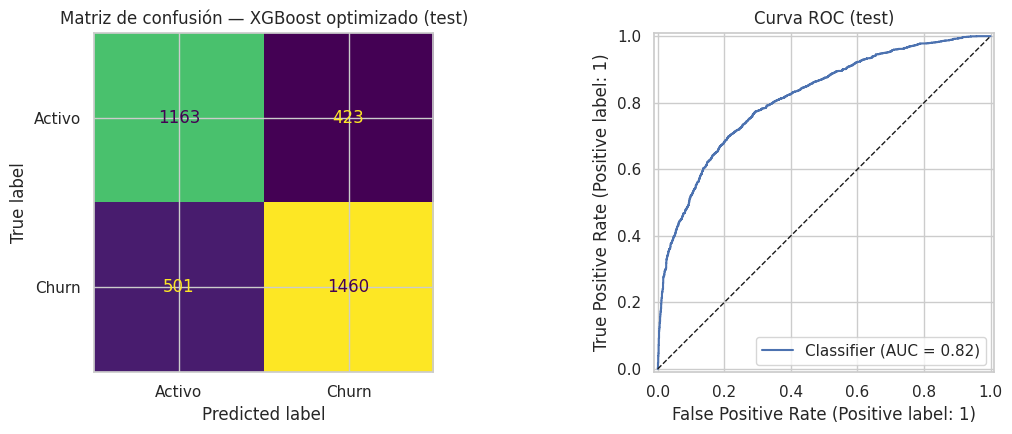

In [8]:
rs = RandomizedSearchCV(
    Pipeline([("prep", prep_c), ("modelo", XGBClassifier(eval_metric="logloss", random_state=SEED))]),
    param_distributions={
        "modelo__n_estimators": [200, 400, 700],
        "modelo__max_depth": [3, 4, 6, 8],
        "modelo__learning_rate": [0.03, 0.06, 0.1],
        "modelo__subsample": [0.8, 0.9, 1.0],
        "modelo__colsample_bytree": [0.7, 0.9, 1.0],
        "modelo__min_child_weight": [1, 5, 10],
    },
    n_iter=20, cv=cv5, scoring="roc_auc", random_state=SEED, n_jobs=-1,
).fit(X_tr, y_tr)

mejor_clf = rs.best_estimator_
proba_te = mejor_clf.predict_proba(X_te)[:, 1]
pred_te = (proba_te >= 0.5).astype(int)
print("Mejores hiperparámetros:", rs.best_params_)
print(f"AUC (cv) = {rs.best_score_:.3f} | AUC (test) = {roc_auc_score(y_te, proba_te):.3f}")
print(f"Exactitud = {accuracy_score(y_te, pred_te):.3f} | Precisión = {precision_score(y_te, pred_te):.3f} | "
      f"Recall = {recall_score(y_te, pred_te):.3f} | F1 = {f1_score(y_te, pred_te):.3f}")

fig, axes = plt.subplots(1, 2, figsize=(12, 4.5))
ConfusionMatrixDisplay(confusion_matrix(y_te, pred_te),
                       display_labels=["Activo", "Churn"]).plot(ax=axes[0], colorbar=False)
axes[0].set_title("Matriz de confusión — XGBoost optimizado (test)")
RocCurveDisplay.from_predictions(y_te, proba_te, ax=axes[1])
axes[1].plot([0, 1], [0, 1], "k--", lw=1)
axes[1].set_title("Curva ROC (test)")
plt.tight_layout(); plt.show()

**Lectura de métricas:** en un problema de retención, el costo de no detectar un cliente
que se irá (falso negativo) suele superar el de contactar de más (falso positivo); por
eso, junto a la exactitud se prioriza **recall** y **AUC**. Si la campaña tuviera
presupuesto limitado, el umbral de 0.5 puede recalibrarse sobre la curva ROC / precisión-
recall para maximizar el retorno.

## 2.3 Interpretabilidad: importancia de variables + SHAP

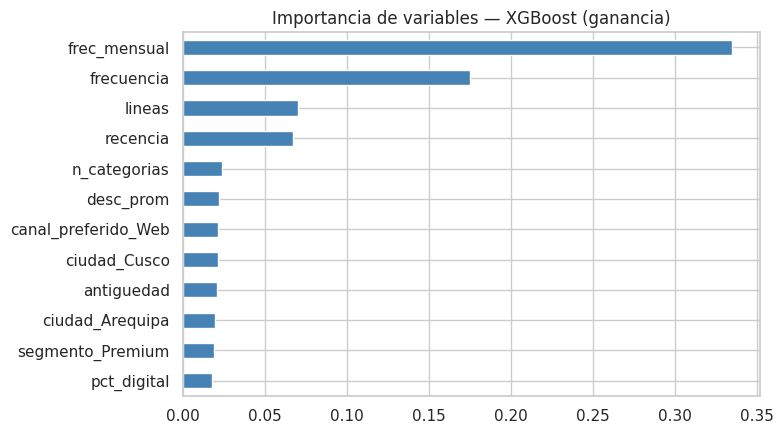

In [9]:
# Importancia por ganancia del XGBoost (sobre las variables transformadas)
ohe = mejor_clf.named_steps["prep"].named_transformers_["cat"]
nombres = FEAT_NUM_C + list(ohe.get_feature_names_out(FEAT_CAT_C))
imp = pd.Series(mejor_clf.named_steps["modelo"].feature_importances_, index=nombres)
imp.sort_values().tail(12).plot.barh(figsize=(8, 4.5), color="steelblue")
plt.title("Importancia de variables — XGBoost (ganancia)")
plt.tight_layout(); plt.show()

/usr/local/lib/python3.12/dist-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


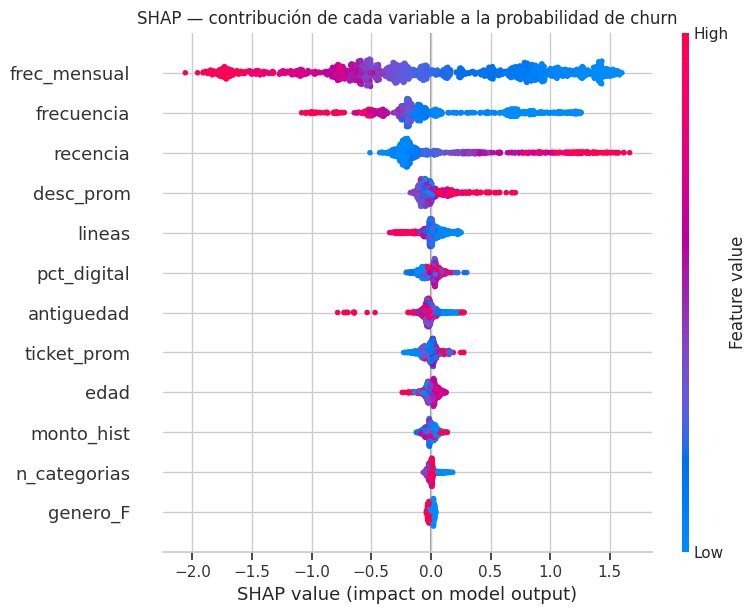

In [10]:
import shap
Xt_te = mejor_clf.named_steps["prep"].transform(X_te)
Xt_te = Xt_te.toarray() if hasattr(Xt_te, "toarray") else np.asarray(Xt_te)
muestra = np.random.default_rng(SEED).choice(Xt_te.shape[0], 1200, replace=False)
explainer = shap.TreeExplainer(mejor_clf.named_steps["modelo"])
shap_values = explainer.shap_values(Xt_te[muestra])
shap.summary_plot(shap_values, Xt_te[muestra], feature_names=nombres,
                  max_display=12, show=False)
plt.title("SHAP — contribución de cada variable a la probabilidad de churn")
plt.tight_layout(); plt.show()

**Interpretación (importancia + SHAP):**
- **Recencia** domina: cuanto más días sin comprar al corte, mayor probabilidad de churn
  (valores altos de recencia empujan la predicción hacia 1 en el gráfico SHAP).
- **Frecuencia mensual y frecuencia total** son el segundo bloque: clientes de compra
  habitual casi no se fugan — exactamente el patrón sembrado en los datos sintéticos y
  detectado en los cuartiles del diccionario de datos.
- Monto histórico, antigüedad y % digital aportan matices de segundo orden; las variables
  demográficas (edad, género, ciudad) pesan poco: el **comportamiento predice mejor que
  el perfil**.

## 3. Conclusiones y recomendaciones (Parte 3)

1. **Forecast operativo:** el XGBoost de demanda (optimizado con `GridSearchCV` +
   `TimeSeriesSplit`) logra alta precisión sobre 2025; los drivers SHAP (rezagos y
   calendario) orientan qué señales monitorear al reentrenar. Habilita compras y
   abastecimiento por categoría × canal (insumo de la Parte 4).
2. **Score de churn accionable:** el clasificador (optimizado con `RandomizedSearchCV`)
   ordena a los clientes por riesgo con AUC alto; operar con listas por decil de riesgo y
   priorizar los deciles superiores que además tengan alto valor (cruce con RFM de la
   Parte 2: "en riesgo valiosos").
3. **Palancas de retención:** la recencia y la frecuencia son las señales dominantes →
   las campañas deben dispararse por **umbrales de recencia** (p. ej. 45–60 días sin
   compra) antes de que el cliente cruce los 90 días de inactividad.
4. **Gobernanza del modelo:** re-entrenar mensualmente moviendo el corte de observación,
   monitoreando MAE/RMSE (demanda) y AUC/recall (churn), más la deriva de las variables
   (el mix digital sigue creciendo).
